# PPE Classification
## 안전모 / 안전조끼 착용 여부 분류

### 파일명 라벨 규칙
```
파일명 형식: XXXX-HV.jpg
              └──┘ └┘
              번호  라벨
                    │└─ V: vest   (1=착용, 0=미착용)
                    └── H: helmet (1=착용, 0=미착용)

예시)
  0001-00.jpg → helmet=0, vest=0
  0002-10.jpg → helmet=1, vest=0
  0003-01.jpg → helmet=0, vest=1
  0004-11.jpg → helmet=1, vest=1
```

---
## 1. 모듈 로딩

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
import os
import time
import shutil
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("NumPy Version      :", np.__version__)
print("TensorFlow Version :", tf.__version__)
print("Matplotlib Version :", plt.matplotlib.__version__)

---
## 2. 실행 환경 감지

In [ ]:
try:
    import google.colab
    colab = True
    print("환경: Google Colab")
except ImportError:
    colab = False
    print("환경: 로컬 (VS Code / Jupyter)")

환경: Google Colab


---
## 3. 경로 설정

### ★ 로컬 실행 시 여기만 수정하세요

```
예시 (Windows) : C:/Users/본인이름/Desktop/PPE_Dataset
예시 (Mac/Linux): /Users/본인이름/Desktop/PPE_Dataset
```

In [ ]:
# ============================================================
#  ★ 로컬 실행 시 아래 두 경로를 본인 환경에 맞게 수정하세요
# ============================================================
LOCAL_DATA_PATH = r'C:/Users/본인이름/Desktop/PPE_Dataset'   # 이미지 폴더
LOCAL_SAVE_PATH = r'C:/Users/본인이름/Desktop/PPE_save'      # 모델 저장 폴더
# ============================================================

if colab:
    # ── Colab: Drive 마운트 후 zip 압축 해제 ──
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive 마운트 완료')

    #!unzip -q -o /content/drive/MyDrive/files/PPE_Dataset.zip -d /content/
    files_path = '/content/drive/MyDrive/프로젝트/Result'
    save_dir   = '/content/drive/MyDrive/files/save/'
else:
    # ── 로컬: 위에서 설정한 경로 사용 ──
    files_path = LOCAL_DATA_PATH
    save_dir   = LOCAL_SAVE_PATH

os.makedirs(save_dir, exist_ok=True)

print(f"\n데이터 경로 : {files_path}")
print(f"저장 경로   : {save_dir}")

# 경로 존재 여부 확인
if not os.path.exists(files_path):
    print(f"\n⚠️  경로를 찾을 수 없어요: {files_path}")
    print("   LOCAL_DATA_PATH 를 올바르게 수정해 주세요.")
else:
    img_count = len(glob.glob(files_path + '/*.*'))
    print(f"\n✅ 경로 확인 완료  ({img_count}개 파일 발견)")

Mounted at /content/drive
Google Drive 마운트 완료

데이터 경로 : /content/drive/MyDrive/프로젝트/Result
저장 경로   : /content/drive/MyDrive/files/save/

✅ 경로 확인 완료  (4024개 파일 발견)


---
## 4. 파일명 파싱 → 라벨 자동 생성

In [ ]:
def parse_label_from_filename(filepath):
    """
    파일명에서 helmet / vest 라벨을 파싱한다.

    규칙: XXXX_HV.확장자
      H: 0=헬멧 미착용, 1=헬멧 착용
      V: 0=조끼 미착용, 1=조끼 착용

    Returns: [helmet, vest] 또는 파싱 실패 시 None
    """
    name = os.path.splitext(os.path.basename(filepath))[0]  # 확장자 제거

    if '_' not in name:
        print(f"[건너뜀] '_' 없는 파일명: {os.path.basename(filepath)}")
        return None

    label_str = name.split('_')[-1]  # '_' 뒤 마지막 부분

    if len(label_str) < 2:
        print(f"[건너뜀] 라벨 자리수 부족: {os.path.basename(filepath)}")
        return None

    try:
        helmet = int(label_str[0])
        vest   = int(label_str[1])
    except ValueError:
        print(f"[건너뜀] 숫자 아닌 라벨: {os.path.basename(filepath)}")
        return None

    if helmet not in (0, 1) or vest not in (0, 1):
        print(f"[건너뜀] 라벨은 0 또는 1이어야 함: {os.path.basename(filepath)}")
        return None

    return [helmet, vest]


# 파싱 테스트
test_cases = ['0001_00.jpg', '0002_10.jpg', '0003_01.jpg', '0004_11.jpg']
print("파일명 파싱 테스트")
print("-" * 40)
for tc in test_cases:
    lbl = parse_label_from_filename(tc)
    print(f"  {tc:15s} → helmet={lbl[0]}, vest={lbl[1]}")

파일명 파싱 테스트
----------------------------------------
  0001_00.jpg     → helmet=0, vest=0
  0002_10.jpg     → helmet=1, vest=0
  0003_01.jpg     → helmet=0, vest=1
  0004_11.jpg     → helmet=1, vest=1


---
## 5. 전체 이미지 로딩

In [ ]:
%%time
IMG_SIZE = 224

# jpg, png, jpeg 모두 탐색
all_files = sorted(
    glob.glob(files_path + '/*.jpg') +
    glob.glob(files_path + '/*.jpeg') +
    glob.glob(files_path + '/*.png')
)
print(f"전체 파일 수: {len(all_files)}개")


def resize_with_padding(img, size=224):
    """
    비율 유지하면서 정사각형으로 변환
    빈 공간은 검은색(0)으로 채움

    예시)
      320×240 입력 → 224×168 리사이즈 → 224×224 캔버스 중앙 배치
    """
    h, w = img.shape[:2]

    # 긴 쪽 기준으로 축소 비율 계산
    scale = size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    # 비율 유지 리사이즈
    img_resized = cv2.resize(img, (new_w, new_h))

    # 검은 배경 캔버스에 중앙 배치
    canvas = np.zeros((size, size, 3), dtype=np.uint8)
    top  = (size - new_h) // 2
    left = (size - new_w) // 2
    canvas[top:top+new_h, left:left+new_w] = img_resized

    return canvas


images  = []
labels  = []
skipped = 0

for fpath in all_files:
    lbl = parse_label_from_filename(fpath)
    if lbl is None:
        skipped += 1
        continue

    img = cv2.imread(fpath, cv2.IMREAD_COLOR)
    if img is None:
        print(f"[건너뜀] 이미지 읽기 실패: {os.path.basename(fpath)}")
        skipped += 1
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = resize_with_padding(img, IMG_SIZE)   # ← 여기가 바뀐 부분
    images.append(img)
    labels.append(lbl)

images = np.array(images, dtype=np.uint8)
labels = np.array(labels, dtype=np.float32)

print(f"\n로딩 완료 : {len(images)}장  (건너뜀: {skipped}장)")
print(f"images shape : {images.shape}")
print(f"labels shape : {labels.shape}")

전체 파일 수: 4024개


---
## 6. 클래스 분포 확인

=== 클래스 분포 ===
헬멧  착용(1):     1장   미착용(0):     0장
조끼  착용(1):     0장   미착용(0):     1장

=== 조합별 분포 ===
  helmet=0, vest=0  →      0장
  helmet=1, vest=0  →      1장
  helmet=0, vest=1  →      0장
  helmet=1, vest=1  →      0장


/tmp/ipykernel_2364/495743501.py:26: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2364/495743501.py:26: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2364/495743501.py:26: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2364/495743501.py:26: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2364/495743501.py:26: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2364/495743501.py:26: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2364/495743501.py:26: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tm

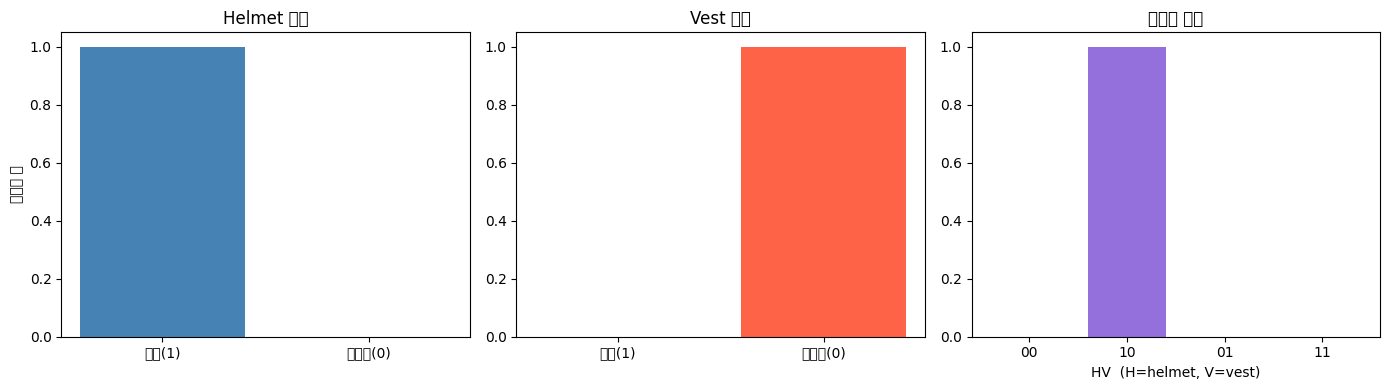

In [ ]:
helmet_on  = int(labels[:, 0].sum())
helmet_off = len(labels) - helmet_on
vest_on    = int(labels[:, 1].sum())
vest_off   = len(labels) - vest_on

combos = {'00': 0, '10': 0, '01': 0, '11': 0}
for lbl in labels:
    combos[f"{int(lbl[0])}{int(lbl[1])}"] += 1

print("=== 클래스 분포 ===")
print(f"헬멧  착용(1): {helmet_on:5d}장   미착용(0): {helmet_off:5d}장")
print(f"조끼  착용(1): {vest_on  :5d}장   미착용(0): {vest_off  :5d}장")
print("\n=== 조합별 분포 ===")
for k, v in combos.items():
    print(f"  helmet={k[0]}, vest={k[1]}  →  {v:5d}장")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(['착용(1)', '미착용(0)'], [helmet_on,  helmet_off], color=['steelblue', 'tomato'])
axes[0].set_title('Helmet 분포')
axes[0].set_ylabel('이미지 수')
axes[1].bar(['착용(1)', '미착용(0)'], [vest_on,    vest_off],   color=['steelblue', 'tomato'])
axes[1].set_title('Vest 분포')
axes[2].bar(list(combos.keys()), list(combos.values()), color='mediumpurple')
axes[2].set_title('조합별 분포')
axes[2].set_xlabel('HV  (H=helmet, V=vest)')
plt.tight_layout()
plt.show()

---
## 7. Train / Test 분리

In [ ]:
train_data, test_data, train_labels, test_labels = train_test_split(
    images, labels,
    test_size    = 0.2,
    random_state = 128
)
print(f"train_data   : {train_data.shape}")
print(f"train_labels : {train_labels.shape}")
print(f"test_data    : {test_data.shape}")
print(f"test_labels  : {test_labels.shape}")

ValueError: With n_samples=1, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

---
## 10. 모델 생성 (MobileNetV2)

In [ ]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

base_model = tf.keras.applications.MobileNetV2(
    weights      = 'imagenet',
    include_top  = False,
    input_tensor = x
)
base_model.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(2, activation='sigmoid', name='ppe_output')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

/tmp/ipykernel_5661/3184917344.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 224, 224,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ subtract[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

---
## 11. 모델 컴파일

In [ ]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = 'binary_crossentropy',
    metrics   = ['binary_accuracy']
)
print("컴파일 완료")

컴파일 완료


---
## 12. 학습 전 결과 시각화

25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step


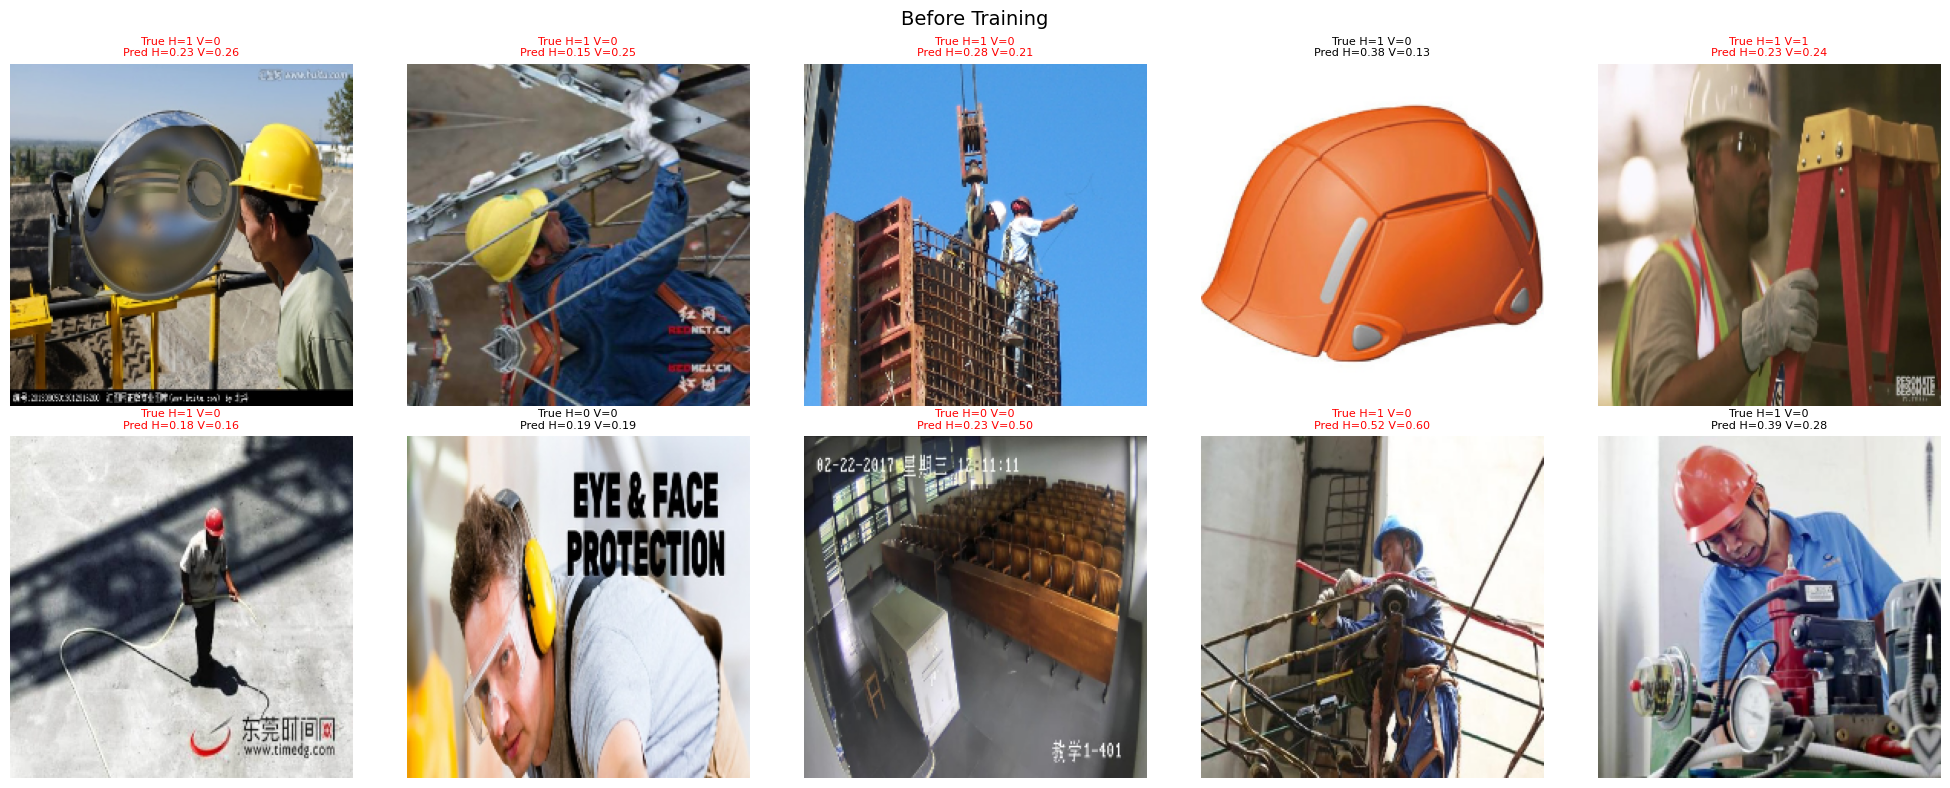

In [ ]:
def Make_Result_Plot(suptitle, data, true_labels, pred_probs, n=10, threshold=0.3):
    size = max(len(data) // n, 1)
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle(suptitle, fontsize=14)
    for idx in range(n):
        cnt = min(idx * size + size // 2, len(data) - 1)
        ax  = axes[idx // 5, idx % 5]
        ax.imshow(data[cnt])
        h_true, v_true   = int(true_labels[cnt][0]), int(true_labels[cnt][1])
        h_pred, v_pred   = pred_probs[cnt][0],       pred_probs[cnt][1]
        h_bin,  v_bin    = int(h_pred >= threshold),  int(v_pred >= threshold)
        color = 'red' if (h_true != h_bin or v_true != v_bin) else 'black'
        ax.set_title(
            f"True H={h_true} V={v_true}\nPred H={h_pred:.2f} V={v_pred:.2f}",
            fontsize=8, color=color
        )
        ax.axis('off')
    plt.tight_layout()
    plt.show()

y_out = model.predict(test_data)
Make_Result_Plot("Before Training", test_data, test_labels, y_out)

---
## 13. 콜백 설정

In [ ]:
saved_model_name = os.path.join(save_dir, 'PPE_MobileNetV2.keras')

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        saved_model_name,
        save_best_only = True,
        monitor        = 'val_binary_accuracy',
        mode           = 'max',
        verbose        = 1
    ),
    tf.keras.callbacks.EarlyStopping(
        patience             = 5,
        monitor              = 'val_binary_accuracy',
        restore_best_weights = True,
        verbose              = 1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        verbose  = 1
    )
]
print(f"모델 저장 위치: {saved_model_name}")

모델 저장 위치: /content/drive/MyDrive/files/save/PPE_MobileNetV2.keras


---
## 14. 모델 학습

In [ ]:
history = model.fit(
    train_data, train_labels,   # ← 이걸로 교체
    epochs          = 30,
    batch_size      = 32,
    callbacks       = callbacks,
    validation_data = (test_data, test_labels)
)

Epoch 1/30
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - binary_accuracy: 0.9492 - loss: 0.1270
Epoch 1: val_binary_accuracy did not improve from 0.92563
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - binary_accuracy: 0.9548 - loss: 0.1195 - val_binary_accuracy: 0.9231 - val_loss: 0.2073 - learning_rate: 5.0000e-05
Epoch 2/30
 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - binary_accuracy: 0.9578 - loss: 0.1168
Epoch 2: val_binary_accuracy did not improve from 0.92563
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - binary_accuracy: 0.9585 - loss: 0.1155 - val_binary_accuracy: 0.9237 - val_loss: 0.2057 - learning_rate: 5.0000e-05
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - binary_accuracy: 0.9580 - loss: 0.1177
Epoch 3: val_binary_accuracy did not improve from 0.92563

Epoch 3: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - binary_accuracy: 0.9581 - loss: 0.1151 - val_binary_accuracy: 0.9206 - val_loss: 0.2124 - learning_rate

---
## 15. 학습 곡선

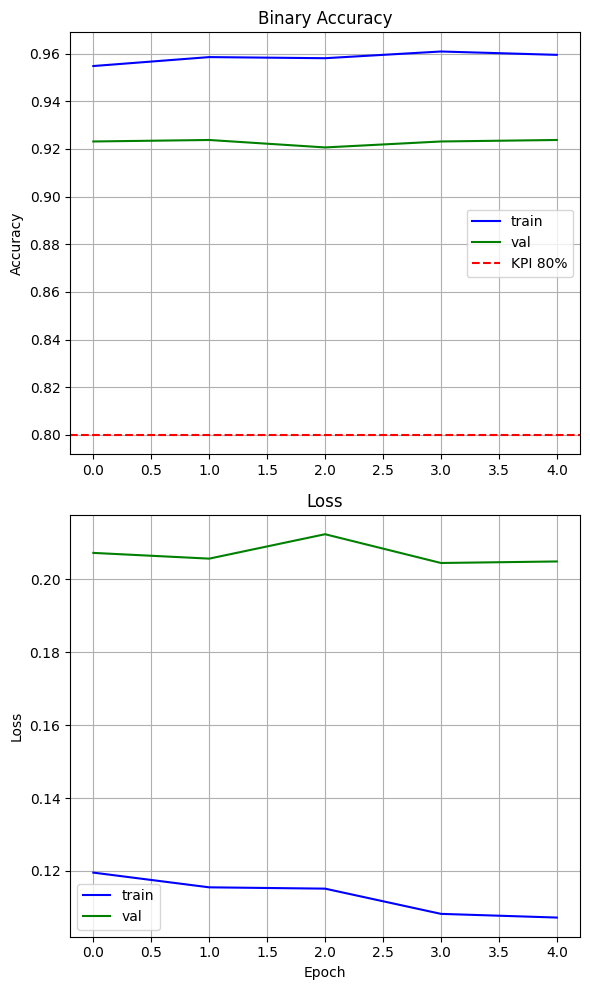

In [ ]:
plt.figure(figsize=(6, 10))

plt.subplot(2, 1, 1)
plt.title('Binary Accuracy')
plt.plot(history.history['binary_accuracy'],     'b', label='train')
plt.plot(history.history['val_binary_accuracy'], 'g', label='val')
plt.axhline(0.80, color='r', linestyle='--', label='KPI 80%')
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(history.history['loss'],     'b', label='train')
plt.plot(history.history['val_loss'], 'g', label='val')
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')

plt.tight_layout()
plt.show()

---
## 16. Best 모델 로딩 & 결과 시각화

25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step


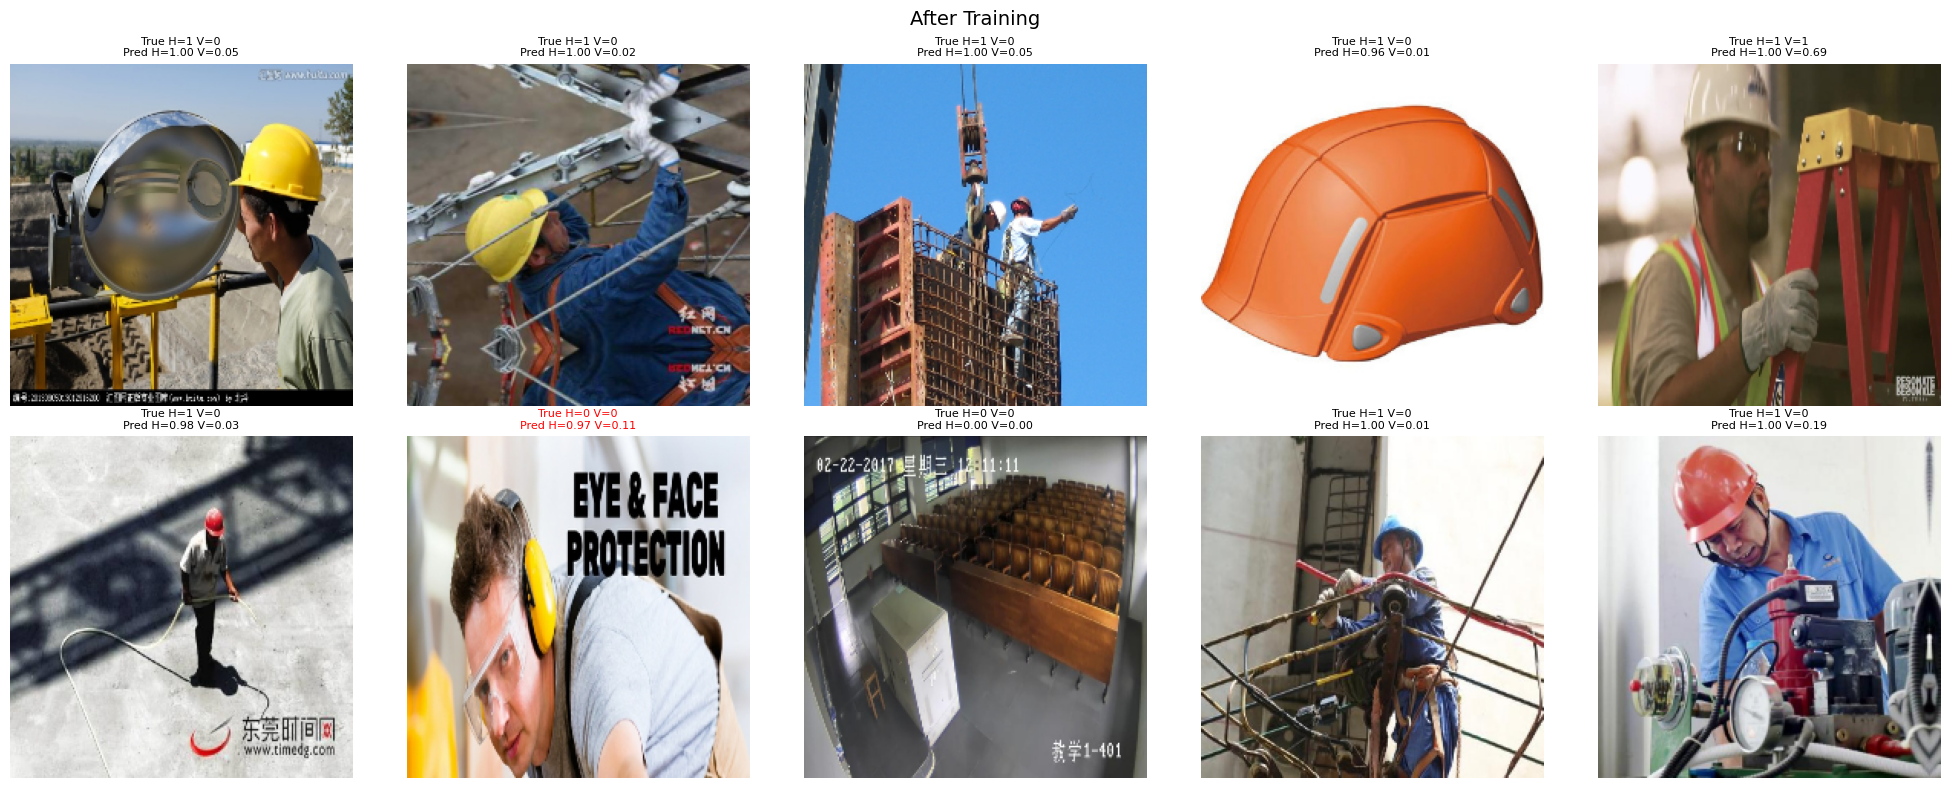

In [ ]:
model_best = tf.keras.models.load_model(saved_model_name)
y_out = model_best.predict(test_data)
Make_Result_Plot("After Training", test_data, test_labels, y_out)

## 17. 혼동행렬 & KPI 확인

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


/tmp/ipykernel_5661/3333104159.py:22: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5661/3333104159.py:22: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5661/3333104159.py:22: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52265 (\N{HANGUL SYLLABLE CAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.

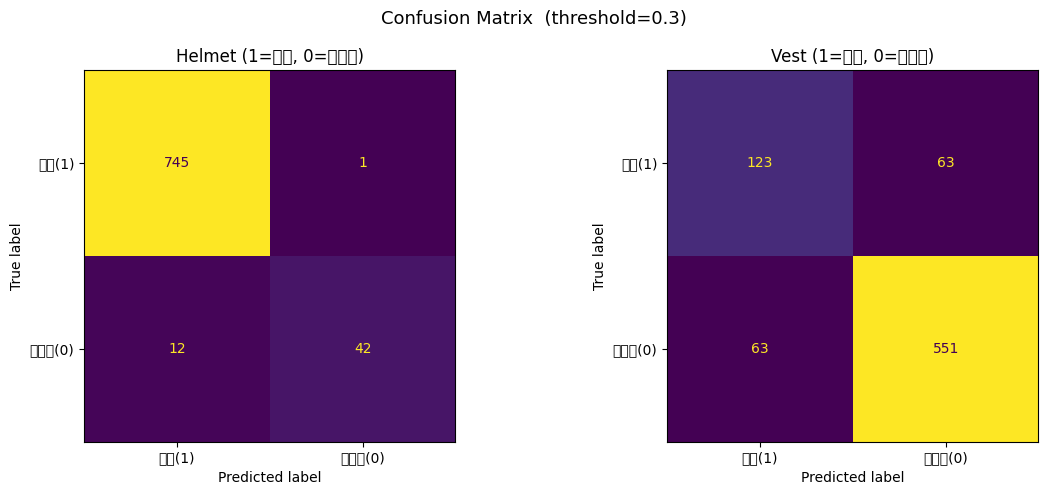

헬멧 정확도 : 98.4%   (KPI ≥ 80%)  ✅
조끼 정확도 : 84.2%   (KPI ≥ 80%)  ✅


In [ ]:
THRESHOLD = 0.3

y_pred      = model_best.predict(test_data)
helmet_true = test_labels[:, 0].astype(int)
helmet_pred = (y_pred[:, 0] >= THRESHOLD).astype(int)
vest_true   = test_labels[:, 1].astype(int)
vest_pred   = (y_pred[:, 1] >= THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, true, pred, title in zip(
    axes,
    [helmet_true, vest_true],
    [helmet_pred, vest_pred],
    ['Helmet (1=착용, 0=미착용)', 'Vest (1=착용, 0=미착용)']
):
    cm   = confusion_matrix(true, pred, labels=[1, 0])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['착용(1)', '미착용(0)'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.suptitle(f'Confusion Matrix  (threshold={THRESHOLD})', fontsize=13)
plt.tight_layout()
plt.show()

helmet_acc = (helmet_true == helmet_pred).mean()
vest_acc   = (vest_true   == vest_pred).mean()
print(f"헬멧 정확도 : {helmet_acc*100:.1f}%   (KPI ≥ 80%)  {'✅' if helmet_acc >= 0.8 else '❌'}")
print(f"조끼 정확도 : {vest_acc  *100:.1f}%   (KPI ≥ 80%)  {'✅' if vest_acc   >= 0.8 else '❌'}")
# ###################예측
#              착용    미착용
# 실제  착용  │ 000  │  00  │
#      미착용 │  00  │ 000  │


---
## 오답이미지 모아보기

In [ ]:
# 오답 이미지 모아보기
def show_wrong_predictions(data, true_labels, pred_probs, threshold=0.3, max_show=20):
    """
    오답 이미지만 골라서 시각화
    """
    wrong_idx = []
    for i in range(len(data)):
        h_true, v_true = int(true_labels[i][0]), int(true_labels[i][1])
        h_pred = int(pred_probs[i][0] >= threshold)
        v_pred = int(pred_probs[i][1] >= threshold)
        if h_true != h_pred or v_true != v_pred:
            wrong_idx.append(i)

    print(f"전체 {len(data)}장 중 오답: {len(wrong_idx)}장")
    print(f"오답률: {len(wrong_idx)/len(data)*100:.1f}%")
    print("-" * 40)

    # 오답 유형별 분류
    types = {'헬멧 오판': 0, '조끼 오판': 0, '둘 다 오판': 0}
    for i in wrong_idx:
        h_true = int(true_labels[i][0])
        v_true = int(true_labels[i][1])
        h_pred = int(pred_probs[i][0] >= threshold)
        v_pred = int(pred_probs[i][1] >= threshold)
        h_wrong = h_true != h_pred
        v_wrong = v_true != v_pred
        if h_wrong and v_wrong:
            types['둘 다 오판'] += 1
        elif h_wrong:
            types['헬멧 오판'] += 1
        else:
            types['조끼 오판'] += 1

    for k, v in types.items():
        print(f"  {k}: {v}장")

    # 최대 max_show 장만 표시
    show_idx = wrong_idx[:max_show]
    n_cols = 5
    n_rows = (len(show_idx) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()
    fig.suptitle(f"오답 이미지 모음 (총 {len(wrong_idx)}장 중 {len(show_idx)}장 표시)", fontsize=14)

    for ax_idx, i in enumerate(show_idx):
        axes[ax_idx].imshow(data[i])
        h_true, v_true = int(true_labels[i][0]), int(true_labels[i][1])
        h_prob, v_prob = pred_probs[i][0],       pred_probs[i][1]
        h_pred = int(h_prob >= threshold)
        v_pred = int(v_prob >= threshold)
        axes[ax_idx].set_title(
            f"정답: H={h_true} V={v_true}\n"
            f"예측: H={h_pred}({h_prob:.2f}) V={v_pred}({v_prob:.2f})",
            fontsize=8, color='red'
        )
        axes[ax_idx].axis('off')

    # 남는 칸 비우기
    for ax_idx in range(len(show_idx), len(axes)):
        axes[ax_idx].axis('off')

    plt.tight_layout()
    plt.show()


# 실행
show_wrong_predictions(test_data, test_labels, y_pred)

Output hidden; open in https://colab.research.google.com to view.

---
## 18. TFLite 변환
### 18-A. Float32

In [ ]:
converter    = tf.lite.TFLiteConverter.from_keras_model(model_best)
tflite_model = converter.convert()

tflite_path = os.path.join(save_dir, 'PPE_MobileNetV2.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"TFLite 저장: {tflite_path}")

Saved artifact at '/tmp/tmpngljlj2a'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136060165697616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136060165700304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136060165699920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136060165701264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136060165697232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136059349901840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136059349902224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136059349902800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136059349901648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136059349900688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136059349898192

### 18-B. INT8 양자화 (Raspberry Pi 5 최적화)

In [ ]:
calib_data = test_data[:100].astype(np.float32)

def representative_dataset():
    for img in calib_data:
        yield [img[np.newaxis, ...]]

conv_int8 = tf.lite.TFLiteConverter.from_keras_model(model_best)
conv_int8.optimizations             = [tf.lite.Optimize.DEFAULT]
conv_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv_int8.inference_input_type      = tf.int8
conv_int8.inference_output_type     = tf.int8
conv_int8.representative_dataset    = representative_dataset

tflite_int8 = conv_int8.convert()
int8_path   = os.path.join(save_dir, 'PPE_MobileNetV2_INT8.tflite')
with open(int8_path, 'wb') as f:
    f.write(tflite_int8)
print(f"INT8 TFLite 저장: {int8_path}")

Saved artifact at '/tmp/tmphln2duxb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136060165697616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136060165700304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136060165699920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136060165701264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136060165697232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136059349901840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136059349902224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136059349902800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136059349901648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136059349900688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136059349898192

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 TFLite 저장: /content/drive/MyDrive/files/save/PPE_MobileNetV2_INT8.tflite


---
## 19. 추론 함수 (Raspberry Pi 5 복사 사용)

In [ ]:
def run_ppe_inference(interpreter, img_bgr, threshold=0.3):
    """
    Parameters
    ----------
    interpreter : tf.lite.Interpreter  (allocate_tensors() 완료 상태)
    img_bgr     : np.ndarray  OpenCV BGR 이미지
    threshold   : float  착용 판정 임계값 (기본 0.3)

    Returns
    -------
    dict  {'helmet': bool, 'vest': bool,
           'helmet_prob': float, 'vest_prob': float}
    """
    inp_d = interpreter.get_input_details()
    out_d = interpreter.get_output_details()

    img_rgb   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_sized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32)
    img_input = img_sized[np.newaxis, ...]

    interpreter.set_tensor(inp_d[0]['index'], img_input)
    interpreter.invoke()
    output = interpreter.get_tensor(out_d[0]['index'])[0]

    return {
        'helmet'      : bool(output[0] >= threshold),
        'vest'        : bool(output[1] >= threshold),
        'helmet_prob' : float(output[0]),
        'vest_prob'   : float(output[1]),
    }


# 동작 확인
interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()

sample_bgr = cv2.cvtColor(test_data[0], cv2.COLOR_RGB2BGR)
result     = run_ppe_inference(interp, sample_bgr)

print("추론 결과 :", result)
print(f"실제 라벨 : helmet={int(test_labels[0][0])}, vest={int(test_labels[0][1])}")

추론 결과 : {'helmet': True, 'vest': False, 'helmet_prob': 0.9988874197006226, 'vest_prob': 0.0881573036313057}
실제 라벨 : helmet=1, vest=0


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
